In [2]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import os
from dotenv import load_dotenv
import requests
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
load_dotenv()

True

In [3]:
# Usable years
years_info = [2000, 2001, 2002, 2003, 2004, 2005,
              2006, 2007, 2008, 2009, 2010, 2011,
              2012, 2013, 2014, 2015, 2016, 2017, 
              2018, 2019, 2020, 2021, 2022]

# Harvest month
harvest_month = 9 # September

# Long, Lat Data
use_maps_api_key = False

# Only to use: 't2m','rh2m','ws10m','ps','frost_days','snodp','pw'
metheorological_vars = ['t2m','rh2m','ws10m','ps','frost_days','snodp','pw']

# Weather data
use_scrap_nasa_weather = False
start_nasa_weather     = 20000101   # Only used if use_scrap_nasa_weather is True
end_nasa_weather       = 20241101   # Only used if use_scrap_nasa_weather is True

The harvest month was selected using [https://ipad.fas.usda.gov/rssiws/al/crop_calendar/europe.aspx](https://ipad.fas.usda.gov/rssiws/al/crop_calendar/europe.aspx), where September is the most common month for harvesting and some data (for the assessment) about seeds is also available (e.g., sunflower).

![](https://ipad.fas.usda.gov/countrysummary/images/E4/cropcalendar/europe_e4_1_calendar.png)


## Data Loading

### Yield Data

In [4]:
# Yield Data
dataset = load_dataset("0x365/crop-yield-eu", split="regional")
df = pd.DataFrame(dataset)

df_tot = df[['province','country']].copy()

harvest_columns = [col for col in df.columns if col.startswith('Harv_')]

df_yield = pd.DataFrame()
for harvest_column in harvest_columns:
    df_tot2 = df_tot.copy()
    df_tot2['crop_yields'] = harvest_column

    df_aux = pd.DataFrame(df[harvest_column].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else []).tolist())
    df_aux.columns = [str(k) for k in range(2000,2025)]
    df_aux = pd.concat([df_tot2, df_aux], axis=1)
    
    df_yield = pd.concat([df_yield, df_aux],ignore_index=True)

df_yield['province'] = df_yield['province'].apply(lambda x: x.lower())
df_yield.head()

,province,country,crop_yields,2000,2001,2002,2003,2004,2005,2006,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,région de bruxelles-capitale/brussels hoofdste...,belgium,Harv_Sunflower_seed,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,prov. antwerpen,belgium,Harv_Sunflower_seed,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,prov. limburg (be),belgium,Harv_Sunflower_seed,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,prov. oost-vlaanderen,belgium,Harv_Sunflower_seed,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,prov. vlaams-brabant,belgium,Harv_Sunflower_seed,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Country Codes

In [5]:
# Country Codes
url = 'https://ec.europa.eu/eurostat/statistics-explained/index.php?title=Tutorial:Country_codes_and_protocol_order'
tablas = pd.read_html(url, attrs={"class": "colheader FCK__ShowTableBorders"})
df_code1 = tablas[0]
df_code1 = df_code1[['English', 'Code']].copy()
df_code1.columns = ['country', 'code']
df_code1['country'] = df_code1['country'].apply(lambda x: x.lower())

df_code2 = tablas[1]
df_code2 = df_code2[['English', 'Code']].copy()
df_code2.columns = ['country', 'code']
df_code2['country'] = df_code2['country'].apply(lambda x: x.lower())

df_code3 = tablas[2]
df_code3 = df_code3[['English', 'Code']].copy()
df_code3.columns = ['country', 'code']
df_code3['country'] = df_code3['country'].apply(lambda x: x.lower())

# In the same document, UK is not in tables, we can assing UK or GB (alpha-2 code)
df_code4 = pd.DataFrame({'country': ['united kingdom'], 'code': ['GB']})

df_code = pd.concat([df_code1, df_code2, df_code3, df_code4], ignore_index=True)

df_code.head()

,country,code
0,belgium,BE
1,bulgaria,BG
2,czechia,CZ
3,denmark,DK
4,germany,DE


In [6]:
# This is the same as df_code but with alpha-2 code from wikipedia
url = 'https://en.wikipedia.org/wiki/ISO_3166-1_alpha-2'
tablas = pd.read_html(url, attrs={"class": "wikitable sortable sort-under"})
df_code_v2 = tablas[0]
df_code_v2 = df_code_v2[['Country name (using title case)', 'Code']].copy()
df_code_v2.columns = ['country', 'code']
df_code_v2['country'] = df_code_v2['country'].apply(lambda x: x.lower())

df_code_v2.head()

,country,code
0,andorra,AD
1,united arab emirates,AE
2,afghanistan,AF
3,antigua and barbuda,AG
4,anguilla,AI


### Localization with Maps

In [7]:
def get_geocode(address, api_key):
    url = "https://maps.googleapis.com/maps/api/geocode/json"
    params = {
        "address": address,
        "key": api_key
    }
    response = requests.get(url, params=params)
    
    if response.status_code == 200:
        data = response.json()
        if data['status'] == 'OK':
            location = data['results'][0]['geometry']['location']
            return location['lat'], location['lng']
        else:
            print(f"Geocoding error: {data['status']}")
    elif response.status_code == 403:
        print("Error 403: Forbidden. Check your API key and permissions.")
    else:
        print(f"HTTP error: {response.status_code}")
    return None


In [8]:
if use_maps_api_key:
    api_key = os.getenv('API_KEY_GEOCODING')
    df_located = df_yield[['province', 'country']].drop_duplicates().copy()
    df_located[['lat', 'long']] = df_located.apply(
        lambda x: pd.Series(get_geocode(f"{x['province']}, {x['country']}", api_key)), 
        axis=1
    )
    df_located.to_csv('../data/located.csv', index=False)
else:
    df_located = pd.read_csv('../data/located.csv')

In [9]:
df_located.head()

,province,country,lat,long
0,région de bruxelles-capitale/brussels hoofdste...,belgium,50.883753,4.370452
1,prov. antwerpen,belgium,51.166364,4.763965
2,prov. limburg (be),belgium,50.973897,5.341968
3,prov. oost-vlaanderen,belgium,51.036210,3.737312
4,prov. vlaams-brabant,belgium,50.881543,4.564597


### Metheorology Data

In [9]:
if use_scrap_nasa_weather:
    df_metheorology = df_located[['province','country','lat','long']].copy()
    df_metheorology['parameters'] = "T2M,RH2M,WS10M,PS,FROST_DAYS,SNODP,PW"

    lst_metheorology = df_metheorology.to_dict(orient="records")

    df_metheorology = pd.DataFrame()
    lst_item_not_found = []
    for item in lst_metheorology:
        province   = item["province"]
        country    = item["country"]
        longitude  = item["long"]
        latitude   = item["lat"]
        parametros = item["parameters"]
        # api_url = f"https://power.larc.nasa.gov/api/temporal/hourly/point?Time=LST&parameters={parametros}&community=RE&longitude={longitude}&latitude={latitude}&start={start}&end={end}&format=JSON&user=DAV"
        api_url = f"https://power.larc.nasa.gov/api/temporal/daily/point?Time=LST&parameters={parametros}&community=AG&longitude={longitude}&latitude={latitude}&start={start_nasa_weather}&end={end_nasa_weather}&format=JSON&user=DAV"
        
        try:
            response = requests.get(api_url)
            response_json = response.json()
            t2m   = response_json["properties"]["parameter"]["T2M"]
            rh2m  = response_json["properties"]["parameter"]["RH2M"]
            ws10m = response_json["properties"]["parameter"]["WS10M"]
            ps    = response_json["properties"]["parameter"]["PS"]
            frday = response_json["properties"]["parameter"]["FROST_DAYS"]
            snodp = response_json["properties"]["parameter"]["SNODP"]
            pw    = response_json["properties"]["parameter"]["PW"]
        
            t2m_df   = pd.DataFrame(t2m, index=[0]).T
            rh2m_df  = pd.DataFrame(rh2m, index=[0]).T
            ws10m_df = pd.DataFrame(ws10m, index=[0]).T
            ps_df    = pd.DataFrame(ps, index=[0]).T
            frday_df = pd.DataFrame(frday, index=[0]).T
            snodp_df = pd.DataFrame(snodp, index=[0]).T
            pw_df    = pd.DataFrame(pw, index=[0]).T

            df_aux = pd.concat([t2m_df, rh2m_df, ws10m_df, ps_df, frday_df, snodp_df, pw_df], axis=1)
            df_aux.columns = ["t2m","rh2m","ws10m","ps","frost_days","snodp","pw"]
            df_aux["province"] = province
            df_aux["country"] = country
            df_aux["date"] = df_aux.index
            df_aux = df_aux.reset_index(drop=True)
            
            df_metheorology = pd.concat([df_metheorology, df_aux], ignore_index=True)
            
            print('------------------------------------------')
            print('GOOD')
            print('item: ',item)
            print('statusCode: ',response.status_code)
            print('body', response.reason)

        except Exception as error:
            print('------------------------------------------')
            print('BAD')
            print('item: ',item)
            print('statusCode: ',response.status_code)
            print('body',"An exception occurred: " + str(error))
            lst_item_not_found.append(item)
            
    df_metheorology.to_csv('../data/metheorology.csv', index=False)
    
else:
    df_metheorology = pd.read_csv('../data/metheorology.csv')    

## DATA PRE-PROCESSING AND EXPLORATION - ALL CROPS

### Yield Data

#### Pre-Process

In [88]:
# Reconstruct data
df_yield_proc = pd.melt(
    df_yield,
    id_vars=["province", "country", "crop_yields"],  
    var_name="year",  
    value_name="yield", 
)

# Filter years
df_yield_proc = df_yield_proc[df_yield_proc['year'].astype(int).isin(years_info)].copy()

# Group by province, country and year
df_yield_proc  = df_yield_proc.groupby(['province', 'country', 'year']).agg({'yield': 'sum'}).reset_index()

# Year to INT
df_yield_proc['year'] = df_yield_proc['year'].astype(int)

df_yield_proc.head()

,province,country,year,yield
0,abruzzo,italy,2000,1637.739987
1,abruzzo,italy,2001,1598.159992
2,abruzzo,italy,2002,1595.639976
3,abruzzo,italy,2003,1340.019975
4,abruzzo,italy,2004,1496.790036


In [89]:
df_yield_proc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9499 entries, 0 to 9498
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   province  9499 non-null   object 
 1   country   9499 non-null   object 
 2   year      9499 non-null   int32  
 3   yield     9499 non-null   float64
dtypes: float64(1), int32(1), object(2)
memory usage: 259.9+ KB


#### Exploration

The first thing I will review is the global data distribution to see if there are any outliers, checking whether there are any at the global level.

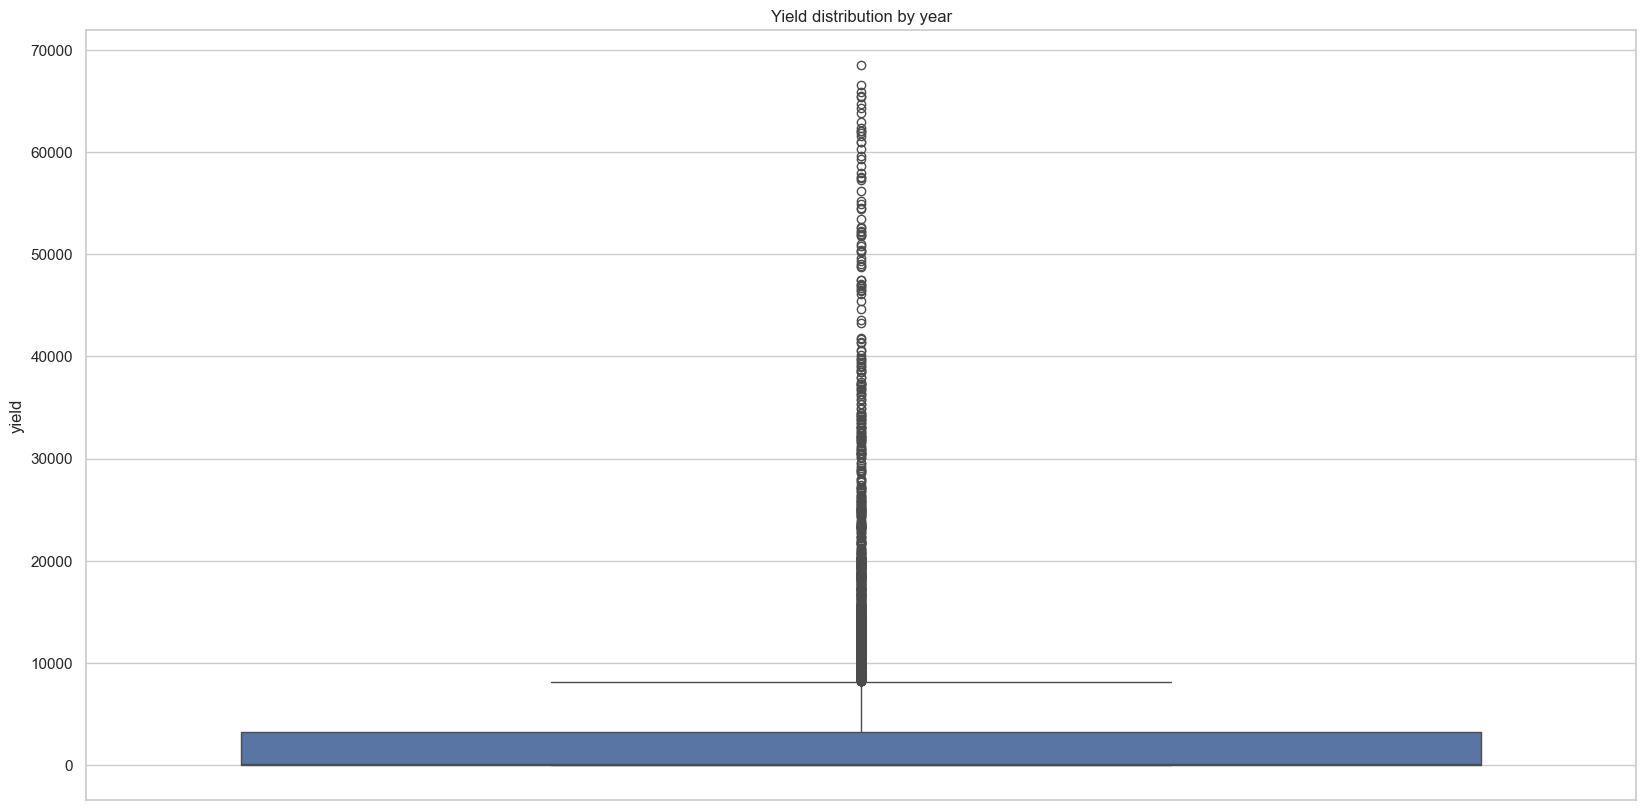

In [71]:
plt.figure(figsize=(20, 10))
sns.boxplot(data=df_yield_proc, y='yield')
plt.title('Yield distribution by year')
plt.show()

Then, I reviewed for distribution and outliers on an annual level, finding that there are also outliers present and similar distributions in less than 10k Tons of yield.

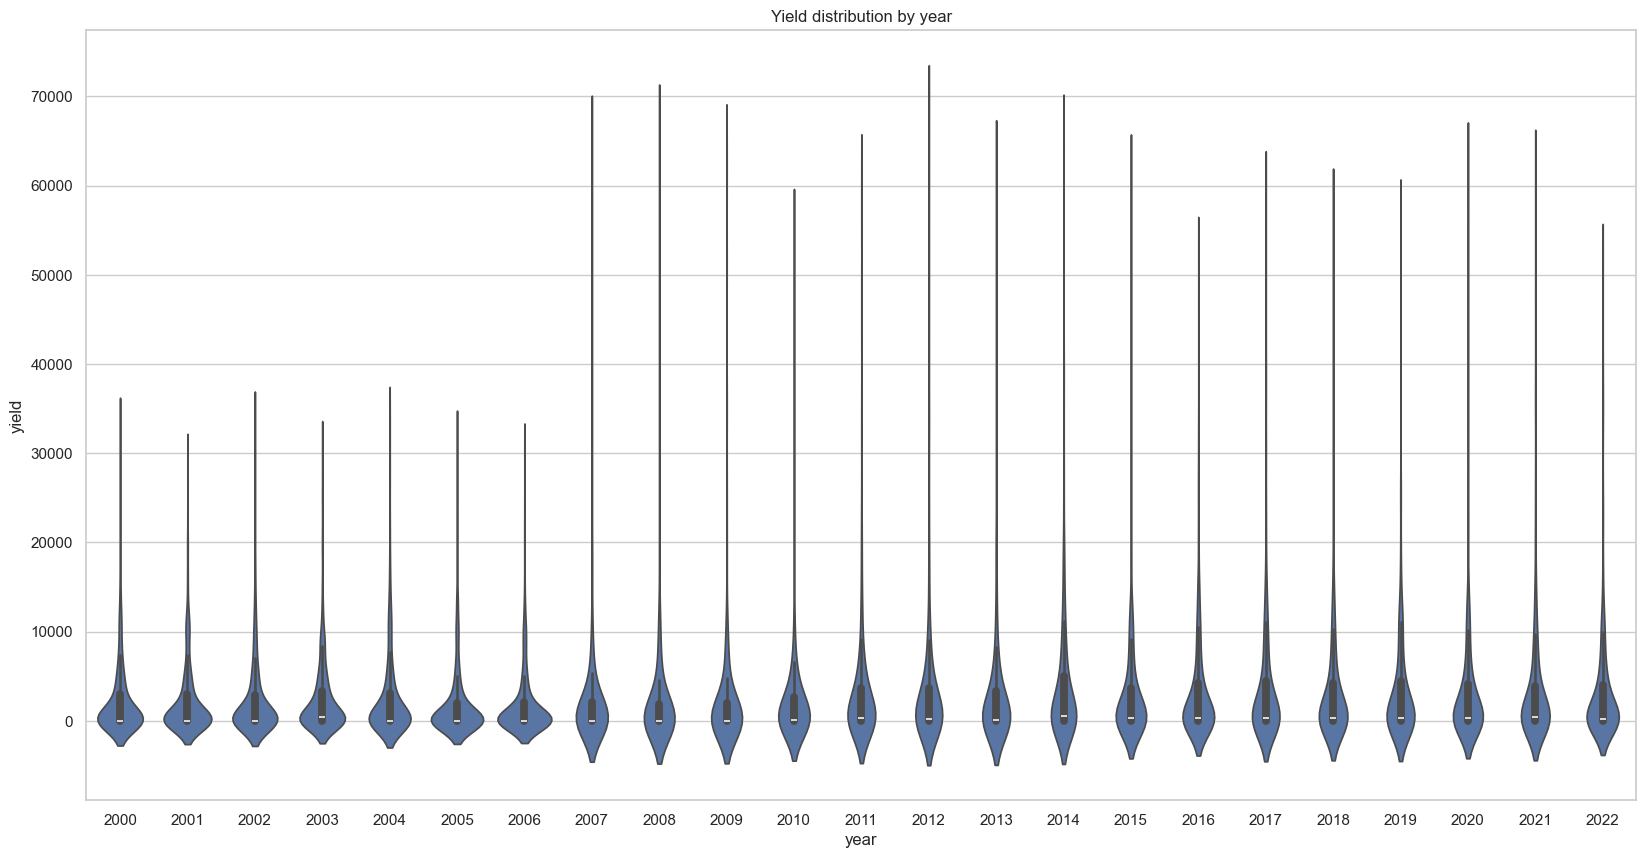

In [72]:
plt.figure(figsize=(20, 10))
sns.violinplot(data=df_yield_proc, x='year', y='yield')
plt.title('Yield distribution by year')
plt.show()

I also reviewed the outliers by country, finding that there is also a presence of them.

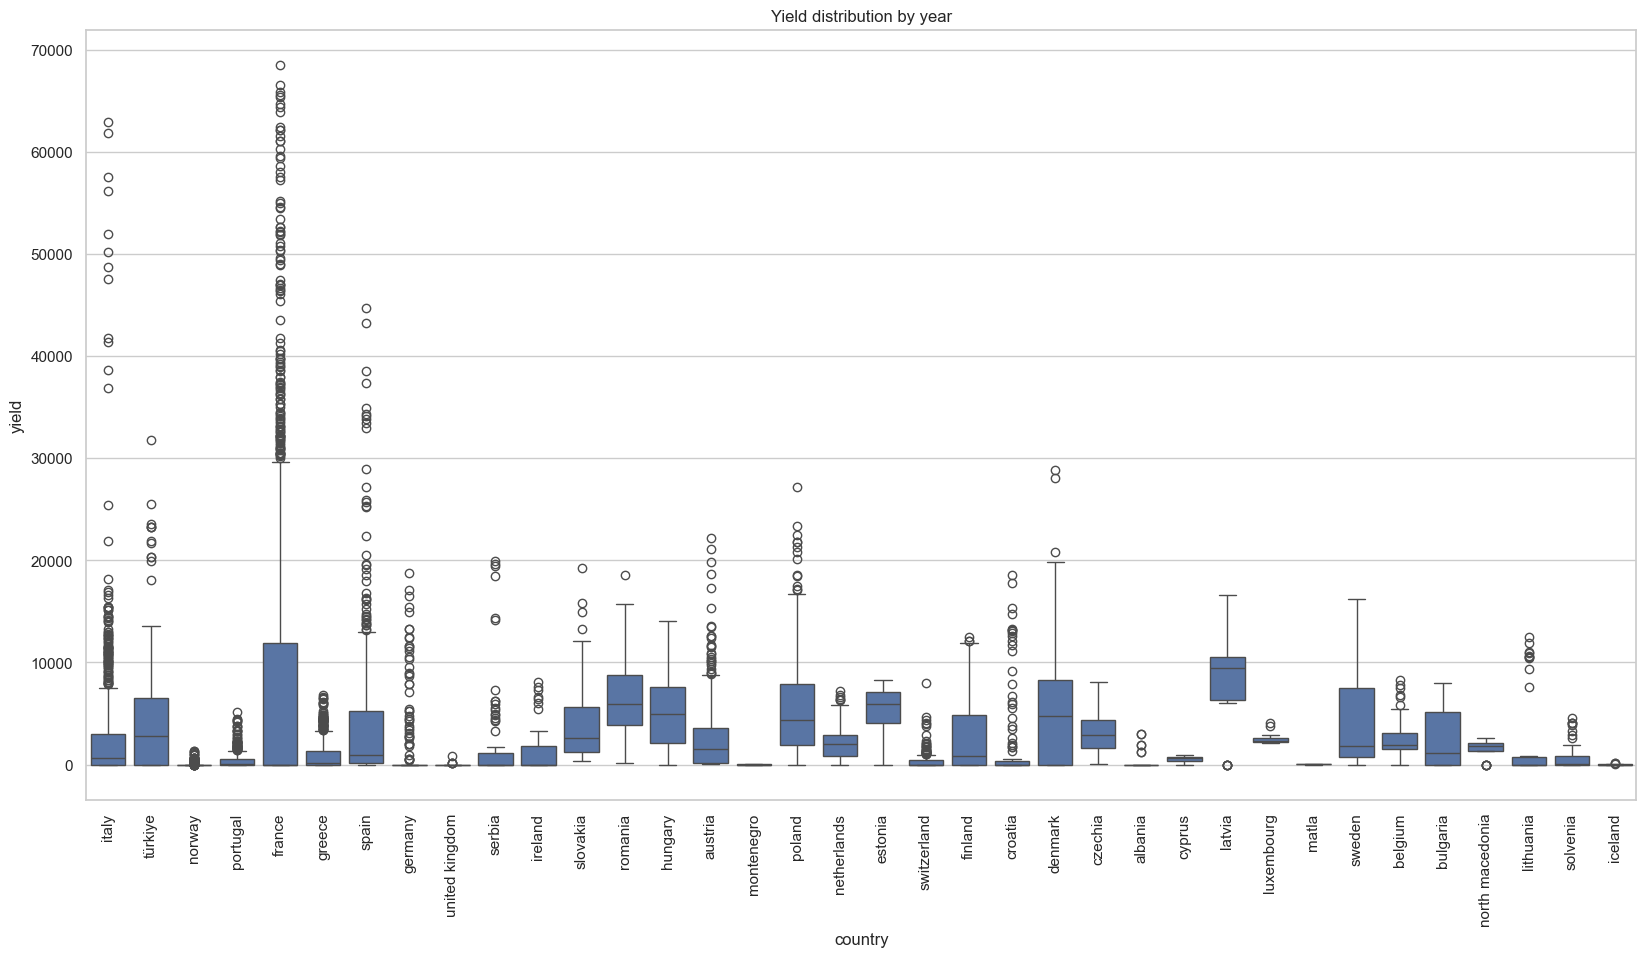

In [73]:
plt.figure(figsize=(20, 10))
sns.boxplot(data=df_yield_proc, x='country', y='yield')
plt.title('Yield distribution by year')
plt.xticks(rotation=90)
plt.show()

Now, the data was grouped by year for each country as requested, showing that France has significantly higher yield compared to other countries. Therefore, the data for France will likely be separated to create a dedicated model for France. This approach does not help to control the outliers for the other countries. Additionally, we can separate the information into high yield, medium yield, and low yield categories for develop different models. All models will be detailed below.

In [74]:
df_yield_f_grouped = df_yield_proc.groupby(['country','year']).agg({'yield':'sum'}).reset_index()
df_yield_f_grouped[df_yield_f_grouped['year']==2012].sort_values(by='yield', ascending=False).head(10)

,country,year,yield
242,france,2012,618207.938248
794,türkiye,2012,184130.000000
725,spain,2012,114679.140022
587,poland,2012,63692.230201
380,italy,2012,52896.320191
748,sweden,2012,52576.820233
311,hungary,2012,50375.140335
518,netherlands,2012,41998.020015
35,austria,2012,38040.120397
58,belgium,2012,34002.900011


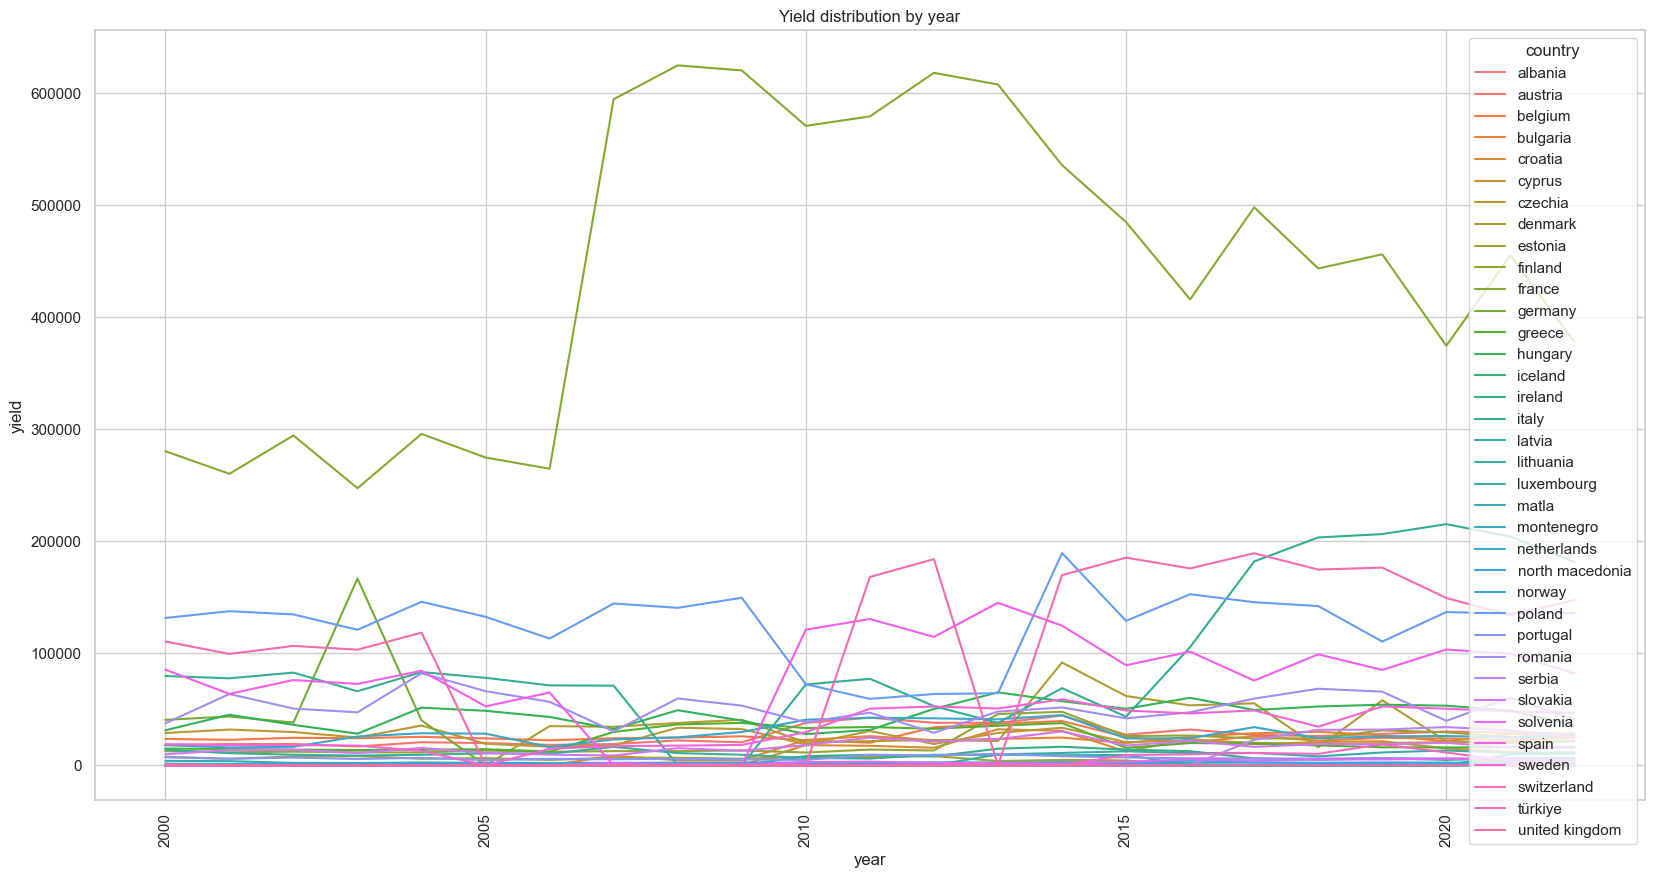

In [75]:
plt.figure(figsize=(20, 10))
sns.lineplot(data=df_yield_f_grouped, 
             x='year', y='yield', hue='country')
plt.title('Yield distribution by year')
plt.xticks(rotation=90)
plt.show()

An additional option is to use a logarithmic transformation of the Yield variable, to capture all the information but on a scaled basis. Later I need to reverse it with exp(yield) - 1 in predictions.

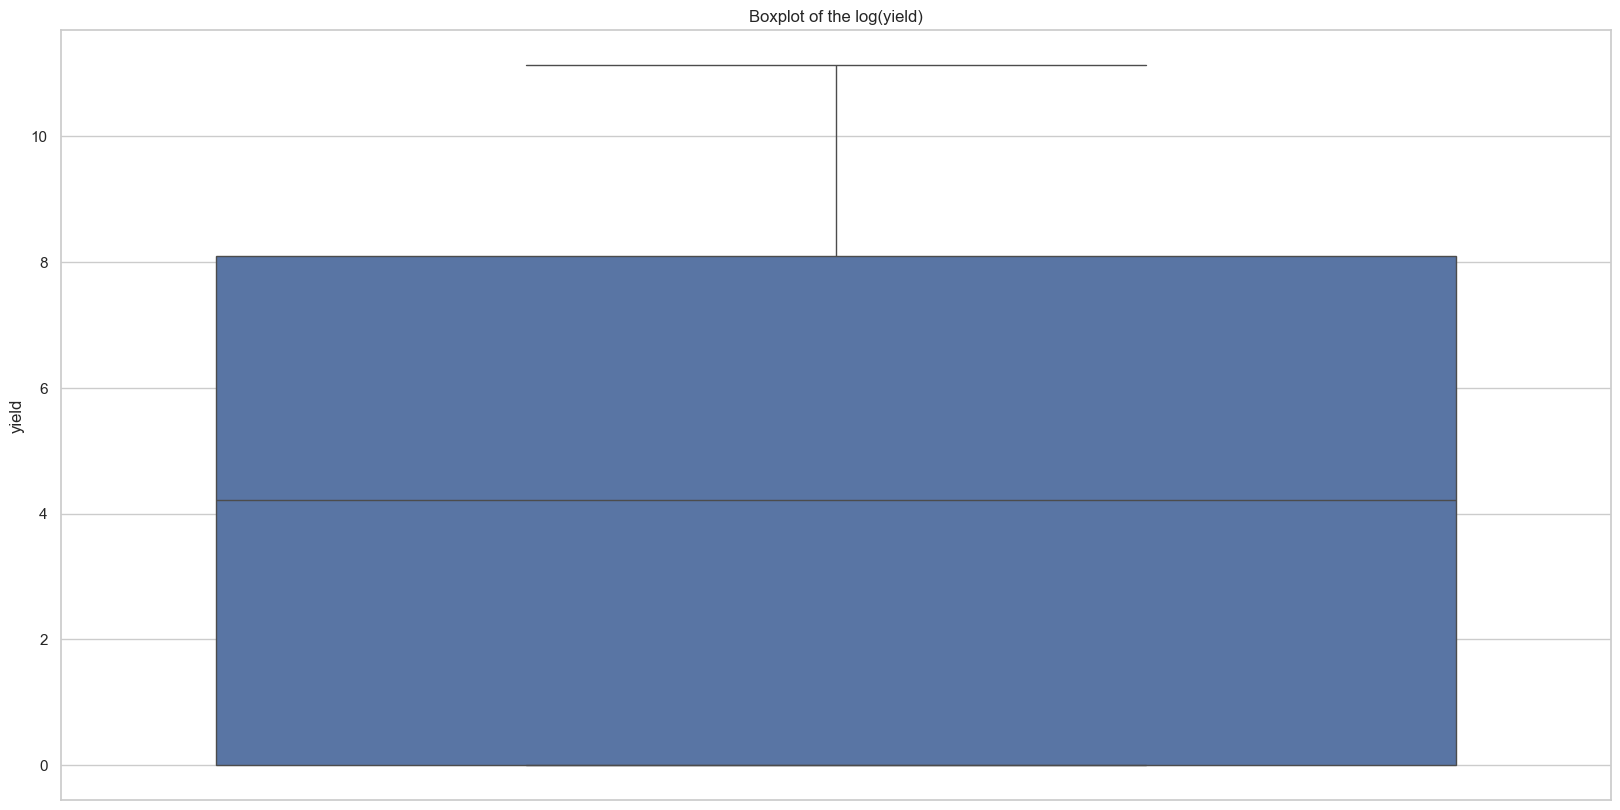

In [76]:
df_yield_f_trans = df_yield_proc.copy()
df_yield_f_trans['yield'] = np.log(df_yield_f_trans['yield']+1)

plt.figure(figsize=(20, 10))
sns.boxplot(data=df_yield_f_trans, y='yield')
plt.title('Boxplot of the log(yield)')
plt.show()

### Metheorological Data

#### Pre-Process

The harvest month was selected using [https://ipad.fas.usda.gov/rssiws/al/crop_calendar/europe.aspx](https://ipad.fas.usda.gov/rssiws/al/crop_calendar/europe.aspx). This serves as a filter to obtain only meteorological information from this month and prior.

![](https://ipad.fas.usda.gov/countrysummary/images/E4/cropcalendar/europe_e4_1_calendar.png)

The meteorological variables were obtained daily, so an average was calculated for each month (temperature, humidity, etc.), and a sum variable was created (frost days). Similarly, the variables to be used depend on the initial setup (for this I put the whole scrapped variables).

In [29]:
# Year and month extraction
df_metheorology_proc = df_metheorology.copy()
df_metheorology_proc = df_metheorology_proc[['province','country','date'] + metheorological_vars].copy()
df_metheorology_proc['year']  = df_metheorology_proc['date'].astype(str).str[:4].astype(int)
df_metheorology_proc['month'] = df_metheorology_proc['date'].astype(str).str[4:6].astype(int)

# Filtering Dataset
# Only years in years_info and months before harvest_month, 
# to get only the data that will be available before the harvest in the year
df_metheorology_proc = df_metheorology_proc[(df_metheorology_proc['year'].isin(years_info)) & 
                                            (df_metheorology_proc['month']<harvest_month)].copy()

# Retrieving -999.0 values to NaN
for col in metheorological_vars:
    df_metheorology_proc[col] = df_metheorology_proc[col].apply(lambda x: x if x != -999.0 else np.nan)
    
# Group by province, country, year and month
df_metheorology_proc = df_metheorology_proc.groupby(['province','country','year','month'])\
                                           .agg({k: 'sum' if k == 'frost_days' else 'mean' for k in metheorological_vars})\
                                           .reset_index()

# Pivot Table for metheorological data                                       
df_metheorology_proc = df_metheorology_proc.pivot(
    index=["province", "country", "year"],  
    columns="month", 
    values=metheorological_vars,  # Expanded Variables
)

# Index Reload
df_metheorology_proc = df_metheorology_proc.reset_index()

# Rename columns
df_metheorology_proc.columns = [
    f"{col[0]}_M{col[1]}" if col[1] else col[0]
    for col in df_metheorology_proc.columns
]

In [30]:
df_metheorology_proc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9499 entries, 0 to 9498
Data columns (total 59 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   province       9499 non-null   object 
 1   country        9499 non-null   object 
 2   year           9499 non-null   int32  
 3   t2m_M1         9499 non-null   float64
 4   t2m_M2         9499 non-null   float64
 5   t2m_M3         9499 non-null   float64
 6   t2m_M4         9499 non-null   float64
 7   t2m_M5         9499 non-null   float64
 8   t2m_M6         9499 non-null   float64
 9   t2m_M7         9499 non-null   float64
 10  t2m_M8         9499 non-null   float64
 11  rh2m_M1        9499 non-null   float64
 12  rh2m_M2        9499 non-null   float64
 13  rh2m_M3        9499 non-null   float64
 14  rh2m_M4        9499 non-null   float64
 15  rh2m_M5        9499 non-null   float64
 16  rh2m_M6        9499 non-null   float64
 17  rh2m_M7        9499 non-null   float64
 18  rh2m_M8 

#### Exploration

As observed, the average or sum is calculated, as appropriate, for the variables on a monthly basis. Each month's variable is separated into a column, where M1 represents the meteorological variable reading for month 1 (January), and so on consecutively.

In [31]:
df_metheorology_proc

,province,country,year,t2m_M1,t2m_M2,t2m_M3,t2m_M4,t2m_M5,t2m_M6,t2m_M7,...,snodp_M7,snodp_M8,pw_M1,pw_M2,pw_M3,pw_M4,pw_M5,pw_M6,pw_M7,pw_M8
0,abruzzo,italy,2000,-0.129677,1.588276,4.154839,8.701667,14.219355,17.828667,18.891613,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,abruzzo,italy,2001,2.929677,1.700000,7.197097,6.281333,13.248710,16.045000,20.192903,...,0.0,0.0,1.164839,0.823214,1.299355,1.099667,1.762903,1.732333,2.071290,2.157097
2,abruzzo,italy,2002,-0.383226,4.061786,5.908065,7.896667,13.072581,19.241000,19.959032,...,0.0,0.0,0.733871,1.016429,0.975161,1.243000,1.688065,2.105000,2.331613,2.419677
3,abruzzo,italy,2003,1.565806,-2.159643,3.962258,6.703333,15.211290,21.048333,22.464194,...,0.0,0.0,0.940968,0.596071,0.842258,1.079000,1.736129,2.281333,2.144516,2.448065
4,abruzzo,italy,2004,0.126129,2.306897,3.473548,7.638000,9.717097,16.201667,20.202258,...,0.0,0.0,0.823548,0.867931,0.984516,1.447667,1.397419,1.953000,2.074839,2.260323
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9494,"şanlıurfa, diyarbakır",türkiye,2018,2.805806,6.335357,10.713548,15.490333,19.478065,25.863000,31.209032,...,0.0,0.0,0.987097,1.136786,1.200000,1.235000,2.132581,1.808667,1.541935,1.700968
9495,"şanlıurfa, diyarbakır",türkiye,2019,-0.097419,2.884286,6.399032,10.752333,18.780323,26.726000,29.812258,...,0.0,0.0,0.930968,0.960357,1.180645,1.405333,1.491935,1.744333,1.494194,1.606774
9496,"şanlıurfa, diyarbakır",türkiye,2020,1.192581,1.316207,9.143548,11.937333,17.500323,24.698667,31.658387,...,0.0,0.0,0.919032,0.937931,1.183548,1.365667,1.472581,1.415667,1.692581,1.496774
9497,"şanlıurfa, diyarbakır",türkiye,2021,2.362258,4.828929,7.198065,15.452667,23.183548,27.124333,32.120323,...,0.0,0.0,0.873226,0.834286,0.952258,1.184000,1.249677,1.270667,1.738065,1.789677


To review the meteorological variables by year, they were grouped and their averages were calculated.

In [32]:
columns_met = df_metheorology_proc.columns[3:]
df_metheorology_proc_group = df_metheorology_proc.groupby(['country','year'])\
                                                 .agg({k: 'mean' for k in columns_met}).reset_index()

In [33]:
df_metheorology_proc_group.head()

,country,year,t2m_M1,t2m_M2,t2m_M3,t2m_M4,t2m_M5,t2m_M6,t2m_M7,t2m_M8,...,snodp_M7,snodp_M8,pw_M1,pw_M2,pw_M3,pw_M4,pw_M5,pw_M6,pw_M7,pw_M8
0,albania,2000,1.052366,4.948506,7.369247,13.878111,18.736667,23.401556,24.780000,26.078710,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,albania,2001,6.586237,6.108095,11.488065,11.158667,17.951505,21.090778,25.439677,26.844194,...,0.0,0.0,1.044624,0.737262,1.140000,1.122333,1.656667,1.556667,1.939462,2.089785
2,albania,2002,3.491613,8.464762,10.109677,12.466667,17.955054,23.491111,25.691935,23.597849,...,0.0,0.0,0.744731,0.846667,1.000215,1.166000,1.618817,1.843111,2.241935,2.224946
3,albania,2003,6.003333,1.072024,6.766022,10.777556,20.730645,25.869556,26.328710,27.119247,...,0.0,0.0,0.945484,0.472262,0.657957,0.995444,1.520860,2.084667,1.799355,1.991290
4,albania,2004,3.008495,5.377931,8.385591,12.973333,14.845376,20.925000,25.200645,23.965591,...,0.0,0.0,0.733226,0.784828,0.899677,1.292778,1.278602,1.900778,1.884409,1.859355


g:\yieldForecasting\backend-python\.venv\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
g:\yieldForecasting\backend-python\.venv\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
g:\yieldForecasting\backend-python\.venv\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
g:\yieldForecasting\backend-python\.venv\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
g:\yieldForecasting\backend-python\.venv\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` f

<Figure size 1200x800 with 0 Axes>

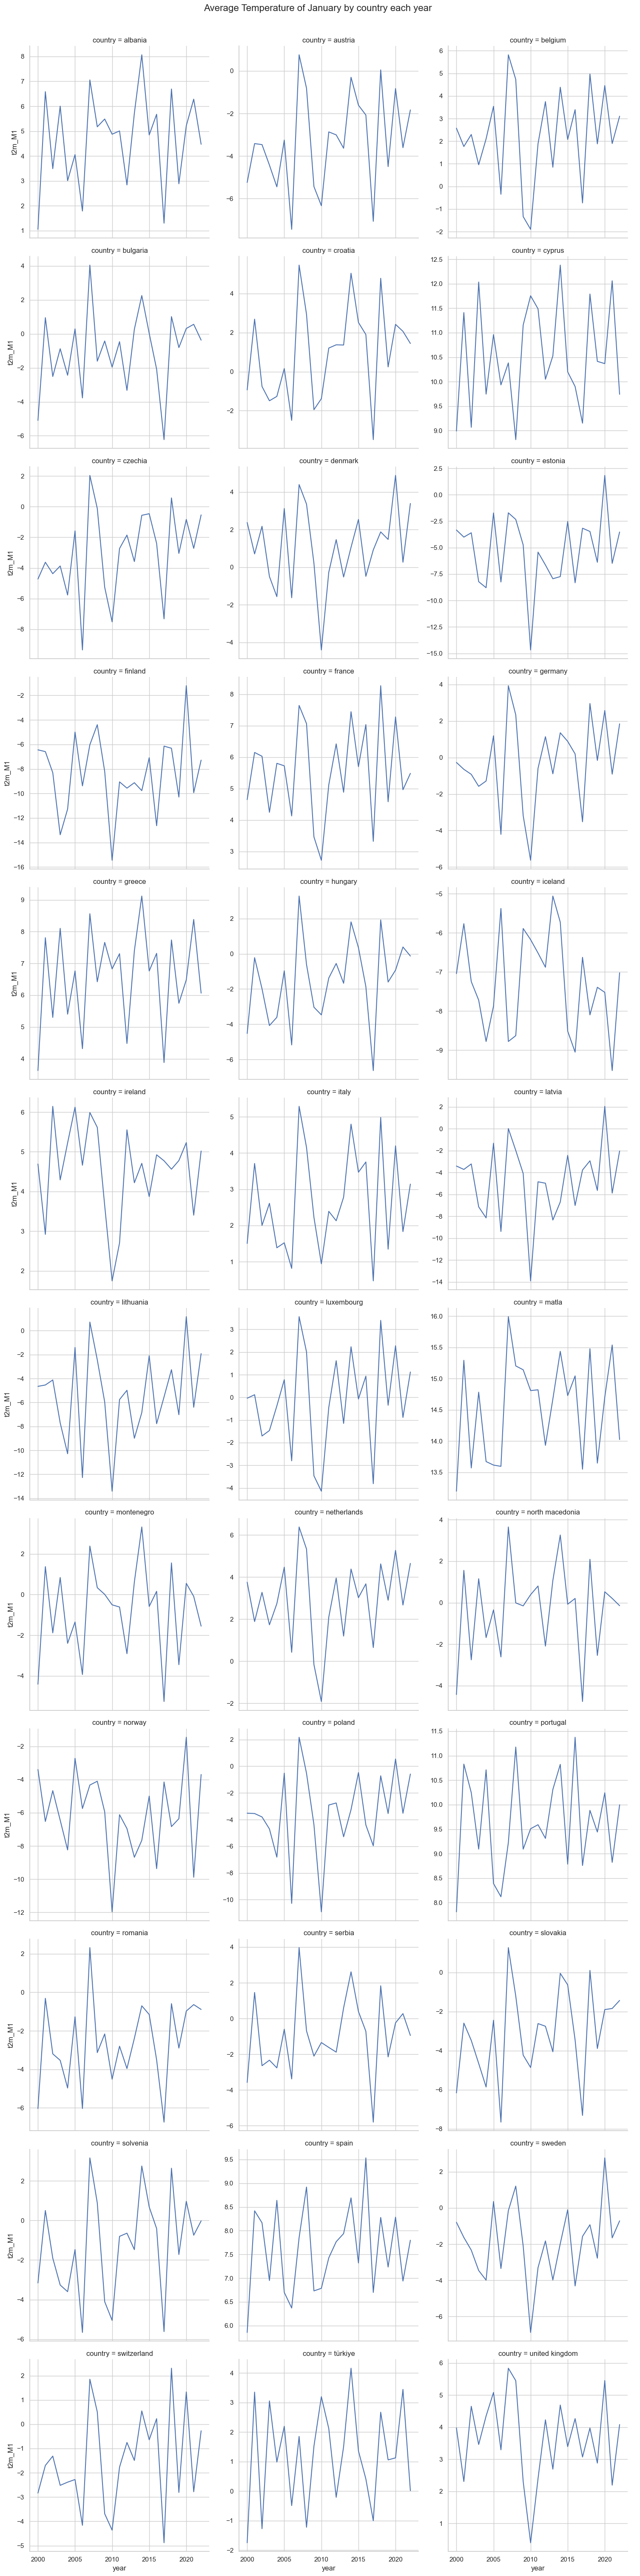

In [34]:
plt.figure(figsize=(12, 8))
g = sns.FacetGrid(df_metheorology_proc_group, col="country", col_wrap=3, height=5, sharey=False)
g.map(sns.lineplot, "year", "t2m_M1", ci=None).add_legend()
g.fig.suptitle("Average Temperature of January by country each year", fontsize=16, y=1.01)
plt.show()


Similarly, we can create a correlation diagram, where outside the groups of lagged variables (e.g., T2M_M1, T2M_M2, etc.), there is a strong inverse correlation between the variables T2M and RH2M, and part of FROST_DAYS and T2M, and a direct correlation between T2M and PW. This could interfere slightly with the development of the model due to multicollinearity; however, relevant variable tests and the use of models that can handle this will be conducted.

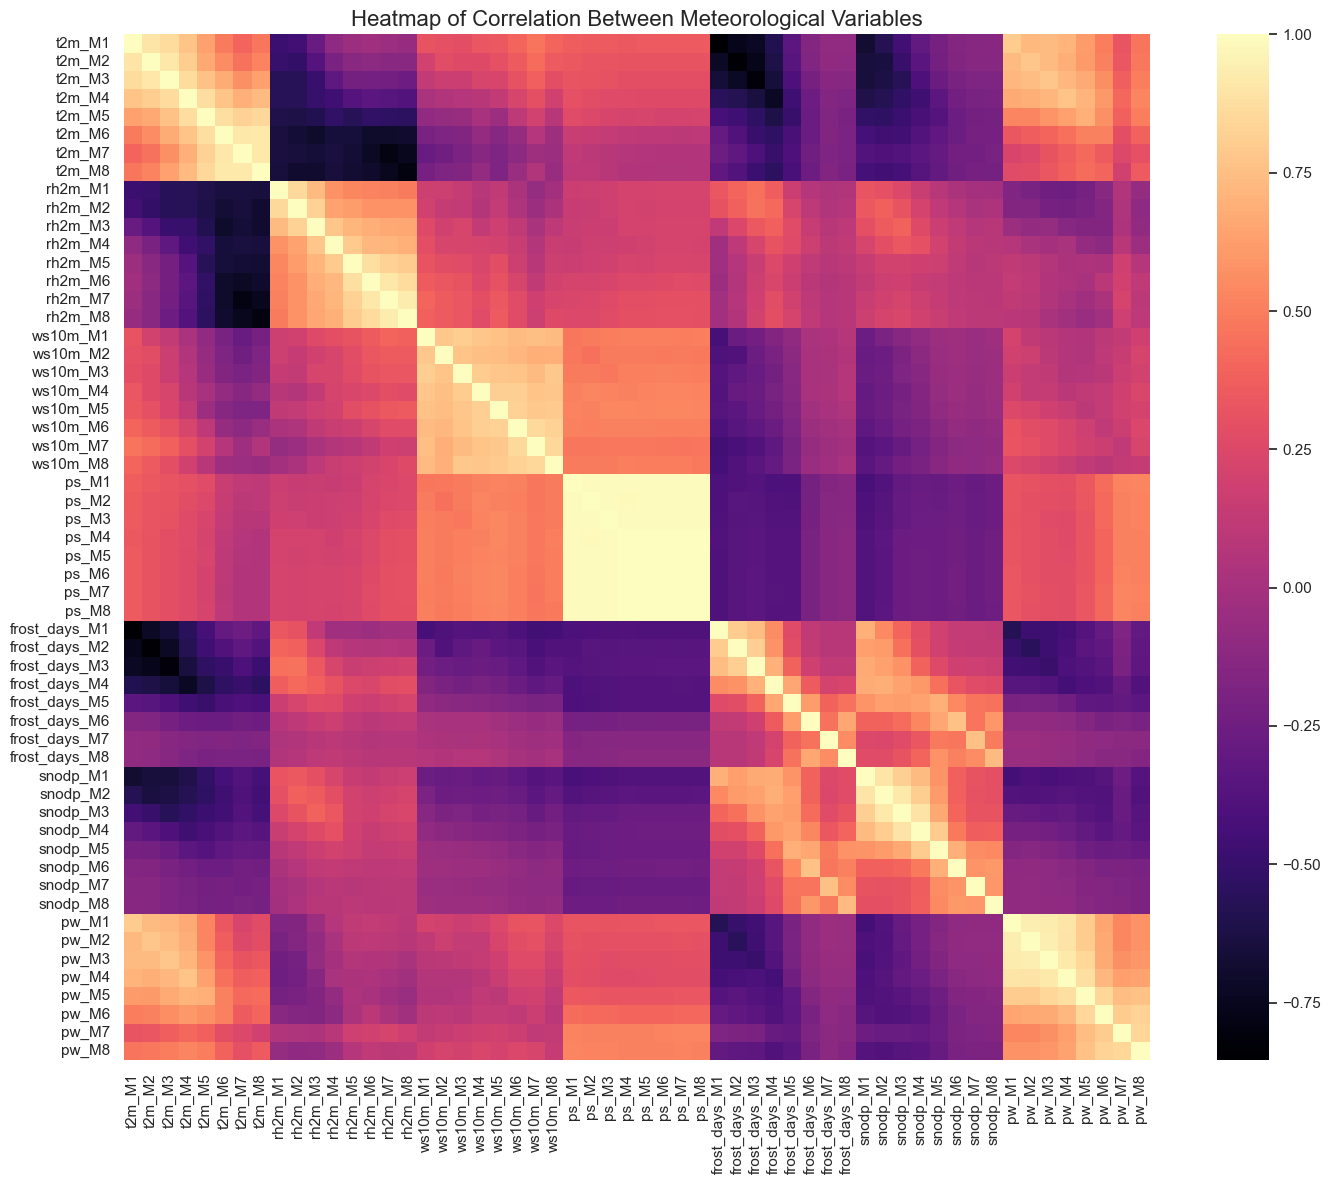

In [35]:
columns_met = df_metheorology_proc.columns[3:]

correlation_matrix = df_metheorology_proc[columns_met].corr()

# Crear un heatmap para visualizar la matriz de correlación
plt.figure(figsize=(15, 12))  # Ajustar el tamaño para acomodar muchas variables
sns.heatmap(correlation_matrix, annot=False, cmap="magma", cbar=True, square=True)
plt.title("Heatmap of Correlation Between Meteorological Variables", fontsize=16)
plt.tight_layout()
plt.show()

### Imputations

Finally, there are null values that can be handled using basic imputation techniques. In this case, we will use the mean of all years for practicality.

In [36]:
import joblib

meth_proc = dict()
columns_imput = [col for col in df_metheorology_proc.columns if col not in ['province','country','year']]

for col in columns_imput:
    meth_proc[col] = float(df_metheorology_proc[col].mean())
    df_metheorology_proc = df_metheorology_proc.fillna(meth_proc[col])

In [37]:
# Save the dictionary as a .joblib file
joblib.dump(meth_proc, '../models/metheorological_imputations.joblib')

['../models/metheorological_imputations.joblib']

## Universe Creation - All Crops

In [90]:
# Clean Data
df_code['country'] = df_code['country'].apply(lambda x: x.lower())

df_yield_proc['province'] = df_yield_proc['province'].apply(lambda x: x.lower())
df_yield_proc['country']  = df_yield_proc['country'].apply(lambda x: x.lower())

df_metheorology_proc['province'] = df_metheorology_proc['province'].apply(lambda x: x.lower())
df_metheorology_proc['country']  = df_metheorology_proc['country'].apply(lambda x: x.lower())

In [91]:
# Merge data sets
data = pd.merge(df_yield_proc, df_metheorology_proc, on=['province','country','year'], how='inner')

# Cleaning country names
data.loc[data['country']=='solvenia', 'country'] = 'slovenia'
data.loc[data['country']=='matla', 'country'] = 'malta'

# Merge with country codes
data = pd.merge(data, df_code, on=['country'], how='left')

In [92]:
df_yield_proc.shape, df_metheorology_proc.shape, data.shape

((9499, 4), (9499, 59), (9499, 61))

In [93]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9499 entries, 0 to 9498
Data columns (total 61 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   province       9499 non-null   object 
 1   country        9499 non-null   object 
 2   year           9499 non-null   int32  
 3   yield          9499 non-null   float64
 4   t2m_M1         9499 non-null   float64
 5   t2m_M2         9499 non-null   float64
 6   t2m_M3         9499 non-null   float64
 7   t2m_M4         9499 non-null   float64
 8   t2m_M5         9499 non-null   float64
 9   t2m_M6         9499 non-null   float64
 10  t2m_M7         9499 non-null   float64
 11  t2m_M8         9499 non-null   float64
 12  rh2m_M1        9499 non-null   float64
 13  rh2m_M2        9499 non-null   float64
 14  rh2m_M3        9499 non-null   float64
 15  rh2m_M4        9499 non-null   float64
 16  rh2m_M5        9499 non-null   float64
 17  rh2m_M6        9499 non-null   float64
 18  rh2m_M7 

In [97]:
data.head()

,province,country,year,yield,t2m_M1,t2m_M2,t2m_M3,t2m_M4,t2m_M5,t2m_M6,...,snodp_M8,pw_M1,pw_M2,pw_M3,pw_M4,pw_M5,pw_M6,pw_M7,pw_M8,code
0,abruzzo,italy,2000,1637.739987,-0.129677,1.588276,4.154839,8.701667,14.219355,17.828667,...,0.0,1.821995,1.821995,1.821995,1.821995,1.821995,1.821995,1.821995,1.821995,IT
1,abruzzo,italy,2001,1598.159992,2.929677,1.700000,7.197097,6.281333,13.248710,16.045000,...,0.0,1.164839,0.823214,1.299355,1.099667,1.762903,1.732333,2.071290,2.157097,IT
2,abruzzo,italy,2002,1595.639976,-0.383226,4.061786,5.908065,7.896667,13.072581,19.241000,...,0.0,0.733871,1.016429,0.975161,1.243000,1.688065,2.105000,2.331613,2.419677,IT
3,abruzzo,italy,2003,1340.019975,1.565806,-2.159643,3.962258,6.703333,15.211290,21.048333,...,0.0,0.940968,0.596071,0.842258,1.079000,1.736129,2.281333,2.144516,2.448065,IT
4,abruzzo,italy,2004,1496.790036,0.126129,2.306897,3.473548,7.638000,9.717097,16.201667,...,0.0,0.823548,0.867931,0.984516,1.447667,1.397419,1.953000,2.074839,2.260323,IT


Now that we have the target variable, as we can see, it does not have a correlation with its independent variables, so there is no variable that significantly influences the decision of the number of tons of Yield.

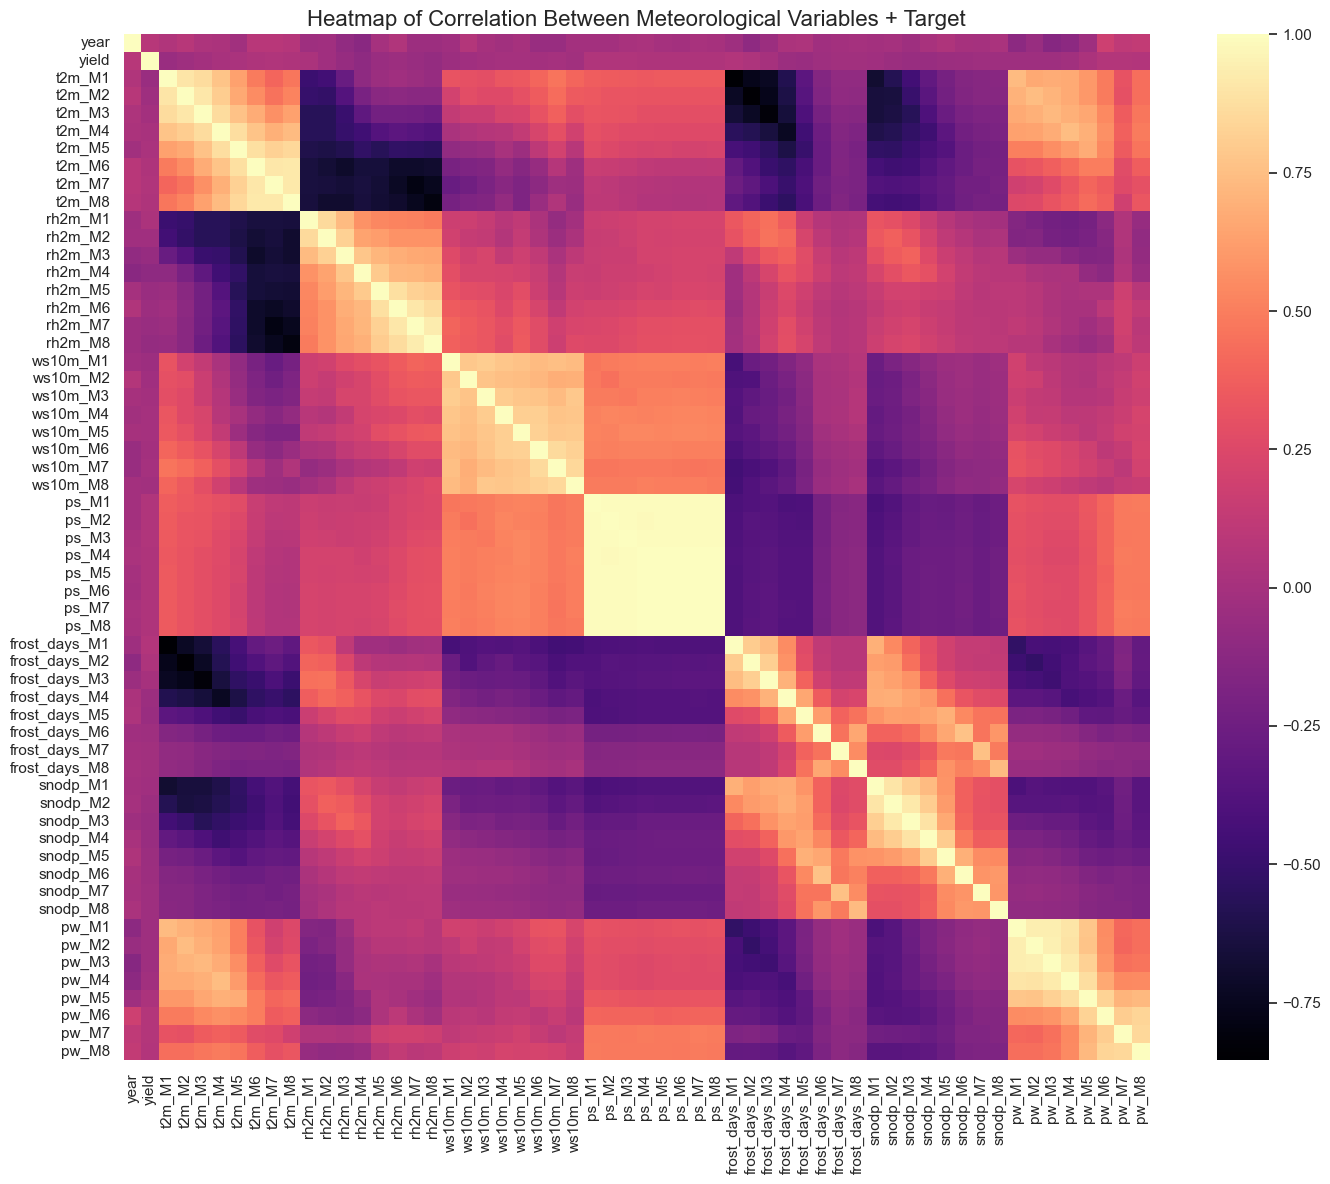

In [100]:
# Only numeric columns
correlation_matrix = data.drop(columns=['province','country','code']).corr()

# Crear un heatmap para visualizar la matriz de correlación
plt.figure(figsize=(15, 12))  # Ajustar el tamaño para acomodar muchas variables
sns.heatmap(correlation_matrix, annot=False, cmap="magma", cbar=True, square=True)
plt.title("Heatmap of Correlation Between Meteorological Variables + Target", fontsize=16)
plt.tight_layout()
plt.show()

In [94]:
# Verifying missing values in code column
data[data['code'].isnull()]['country'].unique()

array([], dtype=object)

In [95]:
# Save the data
data.to_csv('../data/universe.csv', index=False)

## Universe Creation - Top Yield

In [ ]:
# Reconstruct data
df_yield_proc = pd.melt(
    df_yield,
    id_vars=["province", "country", "crop_yields"],  
    var_name="year",  
    value_name="yield", 
)

# Filter years
df_yield_proc = df_yield_proc[df_yield_proc['year'].astype(int).isin(years_info)].copy()

df_yield_proc.head()

,province,country,crop_yields,year,yield
0,région de bruxelles-capitale/brussels hoofdste...,belgium,Harv_Sunflower_seed,2000,0.0
1,prov. antwerpen,belgium,Harv_Sunflower_seed,2000,0.0
2,prov. limburg (be),belgium,Harv_Sunflower_seed,2000,0.0
3,prov. oost-vlaanderen,belgium,Harv_Sunflower_seed,2000,0.0
4,prov. vlaams-brabant,belgium,Harv_Sunflower_seed,2000,0.0


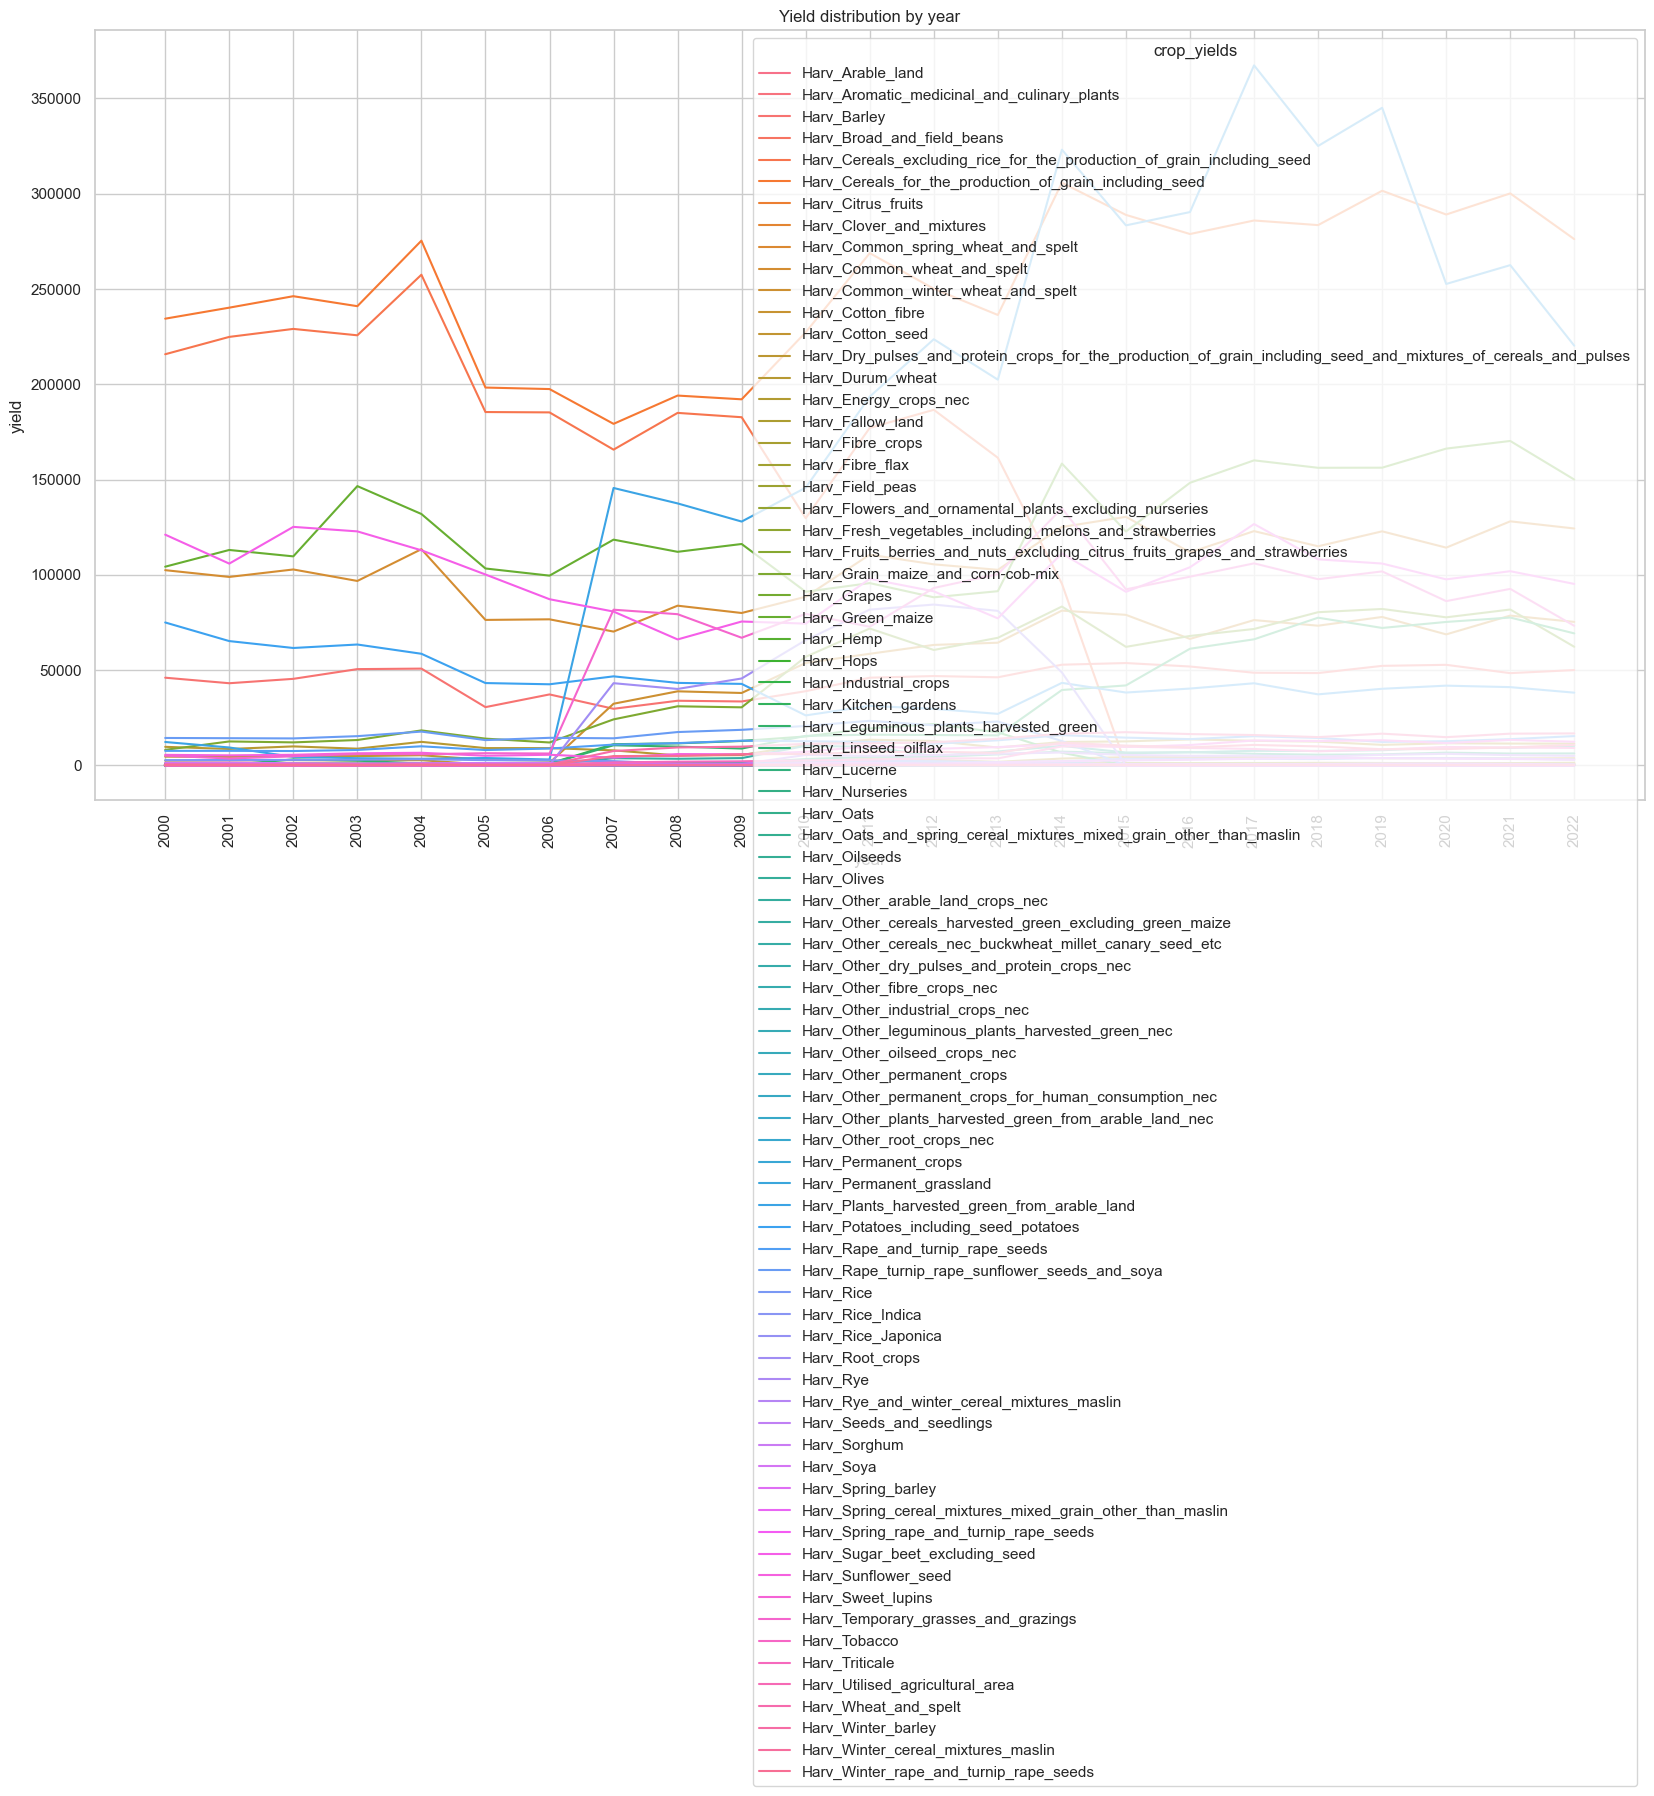

In [19]:
data_grouped = df_yield_proc.groupby(['crop_yields', 'year']).agg({'yield': 'sum'}).reset_index()

plt.figure(figsize=(20, 10))
sns.lineplot(data=data_grouped, 
             x='year', y='yield', hue='crop_yields')
plt.title('Yield distribution by year')
plt.xticks(rotation=90)
plt.show()

Crops were evaluated using advanced metrics: mean yield, standard deviation, cumulative growth, and Sharpe Ratio. This approach identifies the most productive and consistent crop, prioritizing a balance between average yield and stability for top crop.

In [ ]:
# Metrics per serie
evaluation = data_grouped.groupby('crop_yields').agg(
    mean_yield=('yield', 'mean'),
    std_yield=('yield', 'std'),
    cummulative_growth=('yield', lambda x: (x + 1).prod() - 1)
)

# Avoid divisions by zero when calculating the Sharpe Ratio
evaluation['std_yield'] = evaluation['std_yield'].fillna(0.0001)

# Calculate the Sharpe Ratio: average return divided by the standard deviation
evaluation['sharpe_ratio'] = evaluation['mean_yield'] / evaluation['std_yield']

# Identify the series with the best Sharpe Ratio
best_crop = evaluation['sharpe_ratio'].idxmax()
best_values = evaluation.loc[best_crop]

In [26]:
print("TOP CROP:", best_crop)

TOP CROP: Harv_Cereals_for_the_production_of_grain_including_seed


In [40]:
# Reconstruct data with TOP CROP
df_yield_proc = pd.melt(
    df_yield,
    id_vars=["province", "country", "crop_yields"],  
    var_name="year",  
    value_name="yield", 
)

# Filter Crop
df_yield_proc = df_yield_proc[df_yield_proc['crop_yields'] == best_crop].copy()

# Filter years
df_yield_proc = df_yield_proc[df_yield_proc['year'].astype(int).isin(years_info)].copy()

# Group by province, country and year
df_yield_proc  = df_yield_proc.groupby(['province', 'country', 'year']).agg({'yield': 'sum'}).reset_index()

# Year to INT
df_yield_proc['year'] = df_yield_proc['year'].astype(int)

df_yield_proc.head()

,province,country,year,yield
0,abruzzo,italy,2000,421.500000
1,abruzzo,italy,2001,403.899994
2,abruzzo,italy,2002,386.799988
3,abruzzo,italy,2003,348.299988
4,abruzzo,italy,2004,399.700012


In [42]:
# Reusing Clean Data from All Crop Universe
df_code['country'] = df_code['country'].apply(lambda x: x.lower())

df_yield_proc['province'] = df_yield_proc['province'].apply(lambda x: x.lower())
df_yield_proc['country']  = df_yield_proc['country'].apply(lambda x: x.lower())

df_metheorology_proc['province'] = df_metheorology_proc['province'].apply(lambda x: x.lower())
df_metheorology_proc['country']  = df_metheorology_proc['country'].apply(lambda x: x.lower())

In [43]:
# Merge data sets
data = pd.merge(df_yield_proc, df_metheorology_proc, on=['province','country','year'], how='inner')

# Cleaning country names
data.loc[data['country']=='solvenia', 'country'] = 'slovenia'
data.loc[data['country']=='matla', 'country'] = 'malta'

# Merge with country codes
data = pd.merge(data, df_code, on=['country'], how='left')

In [44]:
# Verifying missing values in code column
data[data['code'].isnull()]['country'].unique()

array([], dtype=object)

In [45]:
# Save the data
data.to_csv(f'../data/universe_{best_crop}.csv', index=False)

### JSON Creation for Web APP

In [28]:
df_json = df_located.copy()
df_json = pd.merge(df_json, df_code, on=['country'], how='left')

# Cleaning country names
df_json.loc[df_json['country']=='solvenia', 'country'] = 'slovenia'
df_json.loc[df_json['country']=='matla', 'country'] = 'malta'

In [29]:
df_json['province'] = df_json['province'].apply(lambda x: x.title())
df_json['country'] = df_json['country'].apply(lambda x: x.title())

In [30]:
result = []
for country_code, group in df_json.groupby(['country', 'code']):
    country, code = country_code
    provinces = group.apply(
        lambda row: {
            "name": row['province'],
            "latitude": row['lat'],
            "longitude": row['long']
        },
        axis=1
    ).tolist()
    
    result.append({
        "name": country,
        "code": code,
        "provinces": provinces
    })

In [31]:
import json

json_output = json.dumps(result, indent=2)

with open('countries.json', 'w') as f:
    f.write(json_output)